In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import precision_score, recall_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [8]:
# -----------------------------
# Data (C10+ augmentation)
# -----------------------------
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

trainset = torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)


Files already downloaded and verified
Files already downloaded and verified


In [9]:
# -----------------------------
# ResNet-110 (n=18)
# -----------------------------
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()

        # Option A (identity shortcut with padding)
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.AvgPool2d(2, stride=2),
                nn.ConstantPad3d((0, 0, 0, 0, out_channels//4, out_channels//4), 0)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return torch.relu(out)


class ResNet(nn.Module):
    def __init__(self, n=18):  # n=18 → ResNet-110
        super().__init__()

        self.in_channels = 16

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        self.layer1 = self._make_layer(16, n, stride=1)
        self.layer2 = self._make_layer(32, n, stride=2)
        self.layer3 = self._make_layer(64, n, stride=2)

        self.fc = nn.Linear(64, 10)

    def _make_layer(self, out_channels, blocks, stride):
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = torch.nn.functional.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        return self.fc(out)


model = ResNet().to(device)

# -----------------------------
# FLOPs + Params
# -----------------------------
from thop import profile, clever_format

dummy = torch.randn(1, 3, 32, 32).to(device)
flops, params = profile(model, inputs=(dummy,), verbose=False)
flops, params = clever_format([flops, params], "%.3f")

print("FLOPs:", flops)
print("Params:", params)



FLOPs: 257.088M
Params: 1.728M


In [10]:
# -----------------------------
# Gradient Hooks
# -----------------------------
gradients = {}
grad_history = []

def hook_fn(name):
    def hook(module, grad_input, grad_output):
        gradients[name] = grad_output[0].abs().mean().item()
    return hook

for name, layer in model.named_modules():
    if isinstance(layer, nn.Conv2d):
        layer.register_full_backward_hook(hook_fn(name))

In [11]:

# -----------------------------
# Training Setup
# -----------------------------
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[50,75],
    gamma=0.1
)

num_epochs = 100

history = {
    "Epoch": [],
    "Train Accuracy": [],
    "Test Accuracy Top1": [],
    "Test Accuracy Top5": [],
    "Train Loss": [],
    "Test Loss": [],
    "Precision": [],
    "Recall": []
}

train_acc_hist, test_acc_hist = [], []
train_loss_hist, test_loss_hist = [], []

# -----------------------------
# Evaluation
# -----------------------------
def evaluate(loader):
    model.eval()

    total_loss = 0
    correct1, correct5, total = 0, 0, 0

    all_preds, all_targets = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()

            _, pred1 = out.max(1)
            correct1 += pred1.eq(y).sum().item()

            _, pred5 = out.topk(5, dim=1)
            correct5 += sum(y[i] in pred5[i] for i in range(y.size(0)))

            total += y.size(0)

            all_preds.extend(pred1.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    acc1 = 100 * correct1 / total
    acc5 = 100 * correct5 / total
    loss = total_loss / len(loader)

    precision = precision_score(all_targets, all_preds, average='macro')
    recall = recall_score(all_targets, all_preds, average='macro')

    return loss, acc1, acc5, precision, recall

# -----------------------------
# Training Loop
# -----------------------------
for epoch in range(num_epochs):
    model.train()

    running_loss, correct, total = 0, 0, 0

    for i, (x, y) in enumerate(trainloader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()

        if i == 0:
            grad_history.append(list(gradients.values()))

        optimizer.step()

        running_loss += loss.item()
        _, pred = out.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total

    test_loss, test_acc1, test_acc5, precision, recall = evaluate(testloader)

    scheduler.step()

    train_loss_hist.append(train_loss)
    test_loss_hist.append(test_loss)
    train_acc_hist.append(train_acc)
    test_acc_hist.append(test_acc1)

    history["Epoch"].append(epoch+1)
    history["Train Accuracy"].append(train_acc)
    history["Test Accuracy Top1"].append(test_acc1)
    history["Test Accuracy Top5"].append(test_acc5)
    history["Train Loss"].append(train_loss)
    history["Test Loss"].append(test_loss)
    history["Precision"].append(precision)
    history["Recall"].append(recall)

    print(f"Epoch {epoch+1}: Train Acc {train_acc:.2f}% | Test Acc {test_acc1:.2f}%")




Epoch 1: Train Acc 23.33% | Test Acc 32.49%
Epoch 2: Train Acc 39.41% | Test Acc 43.14%
Epoch 3: Train Acc 47.85% | Test Acc 52.59%
Epoch 4: Train Acc 53.15% | Test Acc 52.76%
Epoch 5: Train Acc 58.92% | Test Acc 55.88%
Epoch 6: Train Acc 63.36% | Test Acc 60.62%
Epoch 7: Train Acc 67.26% | Test Acc 62.25%
Epoch 8: Train Acc 70.26% | Test Acc 65.72%
Epoch 9: Train Acc 72.62% | Test Acc 68.72%
Epoch 10: Train Acc 74.66% | Test Acc 73.47%
Epoch 11: Train Acc 76.46% | Test Acc 72.05%
Epoch 12: Train Acc 77.68% | Test Acc 73.75%
Epoch 13: Train Acc 78.74% | Test Acc 73.71%
Epoch 14: Train Acc 79.87% | Test Acc 75.22%
Epoch 15: Train Acc 81.00% | Test Acc 74.88%
Epoch 16: Train Acc 82.10% | Test Acc 78.08%
Epoch 17: Train Acc 82.57% | Test Acc 77.44%
Epoch 18: Train Acc 83.04% | Test Acc 79.64%
Epoch 19: Train Acc 83.38% | Test Acc 79.21%
Epoch 20: Train Acc 83.83% | Test Acc 77.97%
Epoch 21: Train Acc 84.76% | Test Acc 81.71%
Epoch 22: Train Acc 85.33% | Test Acc 80.41%
Epoch 23: Train Acc

In [12]:
# -----------------------------
# Save Model + Excel
# -----------------------------
torch.save(model.state_dict(), "resnet110.pth")

df = pd.DataFrame(history)
df.to_excel("resnet110_results.xlsx", index=False)


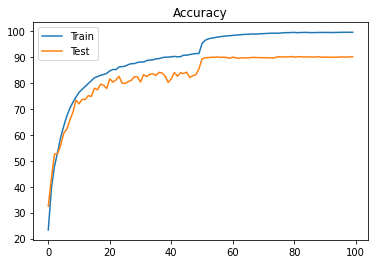

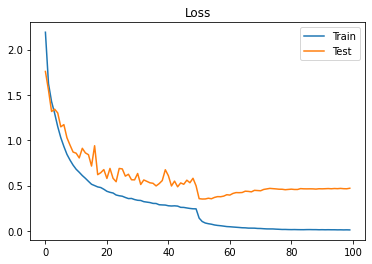

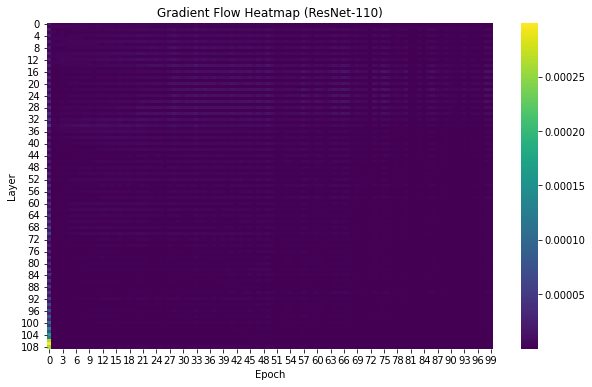

In [13]:
# -----------------------------
# Plots
# -----------------------------
plt.plot(train_acc_hist, label="Train")
plt.plot(test_acc_hist, label="Test")
plt.title("Accuracy")
plt.legend()
plt.show()

plt.plot(train_loss_hist, label="Train")
plt.plot(test_loss_hist, label="Test")
plt.title("Loss")
plt.legend()
plt.show()

# -----------------------------
# Gradient Heatmap
# -----------------------------
grad_matrix = np.array(grad_history).T

plt.figure(figsize=(10,6))
sns.heatmap(grad_matrix, cmap="viridis")
plt.xlabel("Epoch")
plt.ylabel("Layer")
plt.title("Gradient Flow Heatmap (ResNet-110)")
plt.show()

In [14]:
# -----------------------------
# FINAL TEST EVALUATION (AFTER TRAINING)
# -----------------------------
model.eval()

total = 0
correct_top1 = 0
correct_top5 = 0
total_loss = 0

all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in testloader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        total_loss += loss.item()

        # Top-1
        _, pred_top1 = outputs.max(1)
        correct_top1 += pred_top1.eq(targets).sum().item()

        # Top-5
        _, pred_top5 = outputs.topk(5, dim=1)
        correct_top5 += sum([
            targets[i] in pred_top5[i] for i in range(targets.size(0))
        ])

        total += targets.size(0)

        all_preds.extend(pred_top1.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# Final metrics
final_test_acc_top1 = 100. * correct_top1 / total
final_test_acc_top5 = 100. * correct_top5 / total
final_test_loss = total_loss / len(testloader)

precision = precision_score(all_targets, all_preds, average='macro')
recall = recall_score(all_targets, all_preds, average='macro')

test_error = 100 - final_test_acc_top1

print("\n================ FINAL TEST RESULTS ================")
print(f"Top-1 Accuracy  : {final_test_acc_top1:.2f}%")
print(f"Top-5 Accuracy  : {final_test_acc_top5:.2f}%")
print(f"Test Loss       : {final_test_loss:.4f}")
print(f"Test Error %    : {test_error:.2f}%")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print("===================================================")


================ FINAL TEST RESULTS ================
Top-1 Accuracy  : 90.22%
Top-5 Accuracy  : 99.72%
Test Loss       : 0.4713
Test Error %    : 9.78%
Precision       : 0.9029
Recall          : 0.9022


In [15]:
# Save final metrics separately
final_metrics = {
    "Top1 Accuracy": final_test_acc_top1,
    "Top5 Accuracy": final_test_acc_top5,
    "Test Loss": final_test_loss,
    "Test Error": test_error,
    "Precision": precision,
    "Recall": recall
}

pd.DataFrame([final_metrics]).to_excel("resnet110_final_metrics.xlsx", index=False)